In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

apps = pd.read_csv("/content/googleplaystore.csv")
reviews = pd.read_csv("/content/googleplaystore_user_reviews.csv")

print(apps.shape)
print(reviews.shape)

display(apps.head())
display(reviews.head())

(10841, 13)
(64295, 5)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [3]:
apps.info()
apps.describe(include="all")
apps.isnull().sum()
apps.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


np.int64(483)

In [4]:
apps["Reviews"] = pd.to_numeric(apps["Reviews"], errors="coerce")
apps["Installs"] = (
    apps["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .str.replace("Free", "0", regex=False)
    .astype(float)
)

In [5]:
apps["Price"] = (
    apps["Price"]
    .str.replace("$", "", regex=False)
    .apply(pd.to_numeric, errors="coerce")
)

In [6]:
def convert_size(value):
    if value == "Varies with device":
        return np.nan

    if isinstance(value, str):
        if "M" in value:
            return float(value.replace("M", ""))
        elif "k" in value:
            return float(value.replace("k", "")) / 1024

    return np.nan

apps["Size_MB"] = apps["Size"].apply(convert_size)

In [7]:
apps.duplicated().sum()

np.int64(483)

In [8]:
apps = apps.drop_duplicates()

In [9]:
apps.isnull().sum().sort_values(ascending=False)

,0
Size_MB,1527
Rating,1465
Current Ver,8
Android Ver,3
Type,1
Reviews,1
Price,1
Content Rating,1
App,0
Category,0


In [10]:
apps["Size_MB"] = apps["Size_MB"].fillna(0)
apps["Reviews"] = apps["Reviews"].fillna(0)
apps["Price"] = apps["Price"].fillna(0)

In [11]:
apps["Rating"] = apps["Rating"].fillna(apps["Rating"].median())

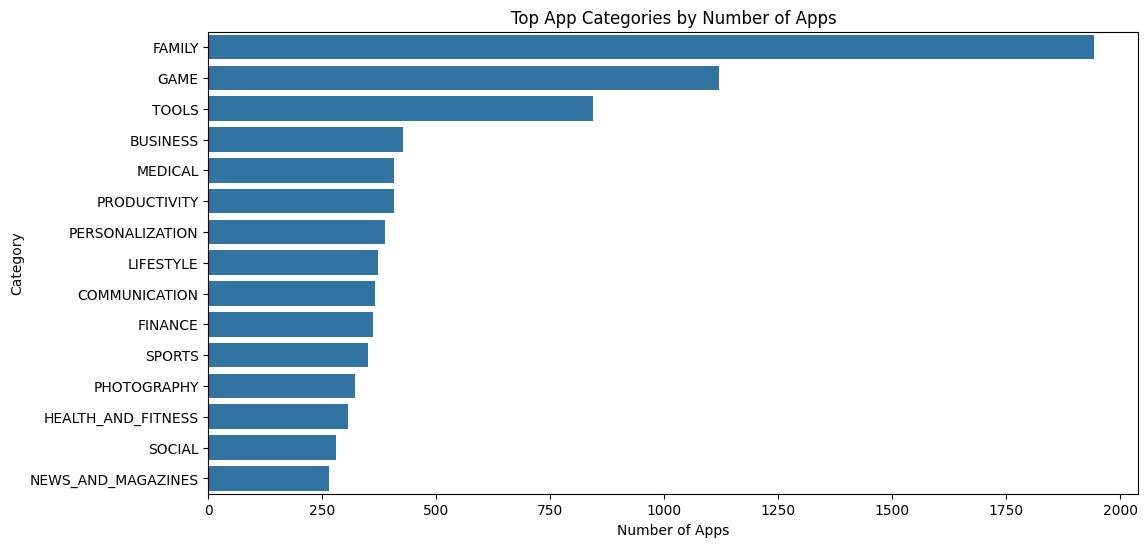

In [12]:
category_counts = apps["Category"].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=category_counts.values[:15],
    y=category_counts.index[:15]
)
plt.title("Top App Categories by Number of Apps")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

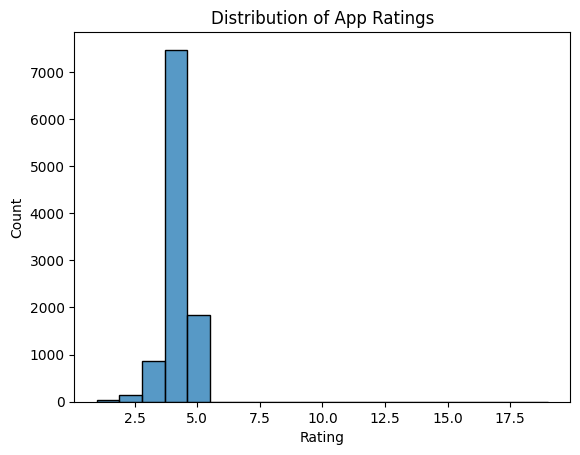

In [13]:
sns.histplot(apps["Rating"].dropna(), bins=20)
plt.title("Distribution of App Ratings")
plt.show()

In [14]:
category_rating = (
    apps.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

display(category_rating)

,Rating
Category,
1.9,19.000000
EVENTS,4.395313
EDUCATION,4.375385
ART_AND_DESIGN,4.355385
BOOKS_AND_REFERENCE,4.336522
PERSONALIZATION,4.327062
PARENTING,4.300000
BEAUTY,4.283019
GAME,4.282070


In [15]:
category_stats = apps.groupby("Category").agg(
    avg_rating=("Rating", "mean"),
    app_count=("App", "count")
)

category_stats = category_stats[
    category_stats["app_count"] >= 10
].sort_values("avg_rating", ascending=False)

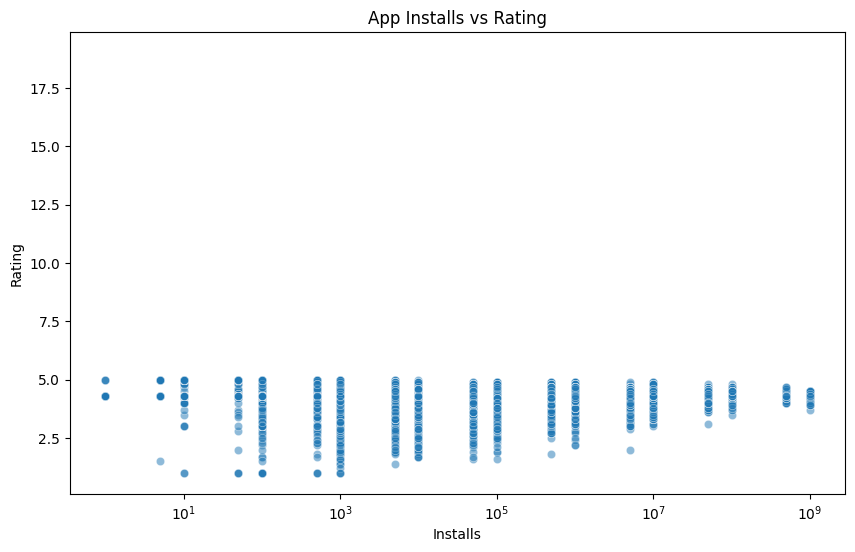

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps,
    x="Installs",
    y="Rating",
    alpha=0.5
)

plt.xscale("log")
plt.title("App Installs vs Rating")
plt.show()

In [17]:
apps[["Installs", "Rating"]].corr()

,Installs,Rating
Installs,1.000000,0.042448
Rating,0.042448,1.000000


In [18]:
apps["Type"].value_counts()

,count
Type,
Free,9591
Paid,765
0,1


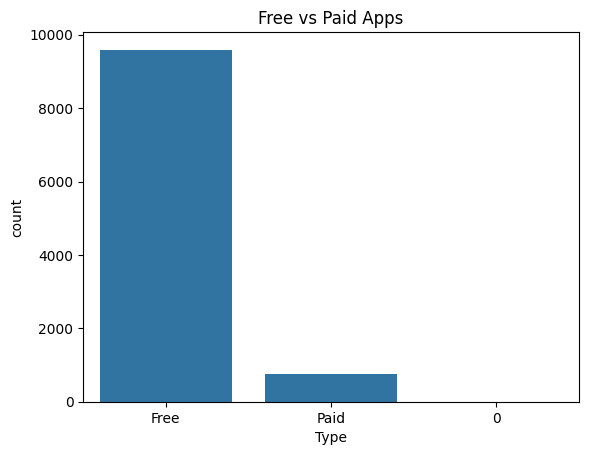

In [19]:
sns.countplot(data=apps, x="Type")
plt.title("Free vs Paid Apps")
plt.show()

In [20]:
apps.groupby("Type")["Rating"].mean()

,Rating
Type,
0,19.000000
Free,4.198509
Paid,4.269150


In [21]:
apps["Estimated_Revenue"] = (
    apps["Installs"] * apps["Price"]
)

In [22]:
revenue_by_category = (
    apps.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [23]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [24]:
reviews["Sentiment"].value_counts()

,count
Sentiment,
Positive,23998
Negative,8271
Neutral,5163


In [25]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

reviews["compound"] = reviews["Translated_Review"].fillna("").apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [26]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

reviews["compound"] = reviews["Translated_Review"].fillna("").apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

reviews["Predicted_Sentiment"] = reviews["compound"].apply(sentiment_label)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [27]:
merged = apps.merge(
    reviews,
    on="App",
    how="left"
)

In [28]:
sentiment_category = pd.crosstab(
    merged["Category"],
    merged["Predicted_Sentiment"],
    normalize="index"
) * 100

In [29]:
import plotly.express as px

fig = px.scatter(
    apps,
    x="Reviews",
    y="Rating",
    size="Installs",
    color="Type",
    hover_name="App",
    log_x=True,
    title="App Rating, Reviews and Install Analysis"
)

fig.show()

## Key Business Insights

1. The Family category has the highest app concentration,
   indicating strong competition and market saturation.

2. Free applications dominate the Play Store dataset,
   suggesting that developers commonly rely on advertising,
   subscriptions, or in-app purchases rather than upfront pricing.

3. User sentiment varies substantially across categories,
   highlighting areas where developers can improve user experience.

4. App popularity and rating do not necessarily move together,
   indicating that high installation volume does not automatically
   imply higher user satisfaction.

5. Revenue estimates show that a small number of paid applications
   can account for a disproportionately large share of estimated
   gross revenue.